/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/matplotlib_inline/backend_inline.py:27: ProplotWarning: Got conflicting figure size arguments figwidth=8 and refwidth=4. Ignoring 'refwidth'.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  return func(self, *args, **kwargs)
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/proplot/figure.py:469: MatplotlibDeprecationWarning: savefig() got unexpected ke

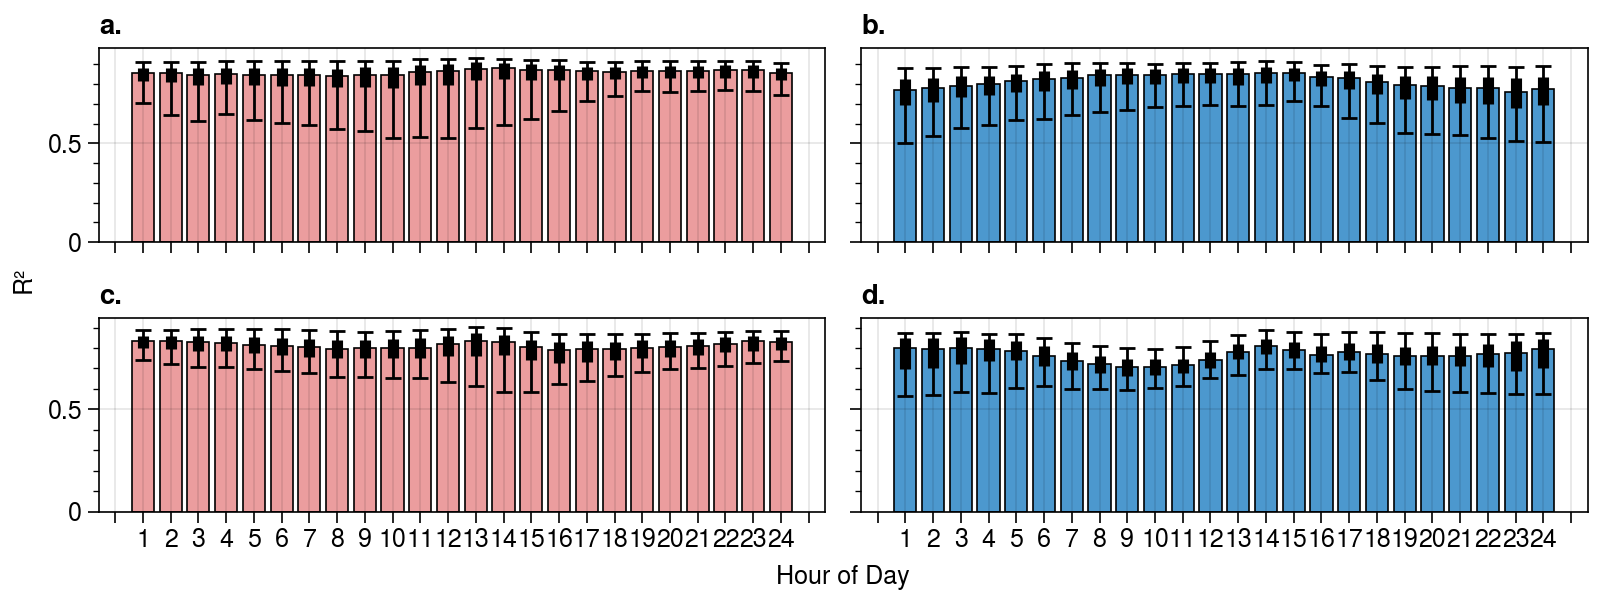

In [32]:
import os
import numpy as np
import pandas as pd
import proplot as pplt


fitting_dir = 'your_directory/loads/fitting_r'
files = sorted([f for f in os.listdir(fitting_dir) if f.endswith('.npz')])
fig, axs = pplt.subplots(ncols=2,nrows=2, figsize=(8, 3), refaspect=1.5,refwidth=4,  share=True)
axs.format(abc='a.')
fig.patch.set_facecolor('white') 
i = 0

for file in files:
    file_path = os.path.join(fitting_dir, file)
    data = np.load(file_path)['fitting_r2']  # shape: (24, N)


    df = pd.DataFrame(data.T, columns=[str(h+1) for h in range(24)])  
    means = df.mean()
    means.name = 'R²'

    if i==1 or i==3:
        axs[i].bar(
            df, color=[76/255.0,152/255.0,206/255.0], edgecolor='k',
            barpctile=90, boxpctile=True,
            legend=False, median=True
        )
    else:
        axs[i].bar(
        df, color=[235/255.0,157/255.0,158/255.0], edgecolor='k',
        barpctile=90, boxpctile=True,
        legend=False, median=True
    )

    axs[i].format(
        xlabel='Hour of Day', ylabel='R²',
        xlocator=1
    )
    i = i+1

pplt.show()


